In [727]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, cohen_kappa_score
import matplotlib.pyplot as plt
import re

In [728]:
emotions_col = ['Wonder', 'Transcendence', 'Nostalgia',
                'Tenderness', 'Peacefulness', 'Joy',
                'Power','Tension','Sadness']

In [729]:
def decode_results(results_file, emotions_col = emotions_col):

    rows = []
 
    with open(results_file, "r") as f:
        
        for line in f:
            line = line.strip()
            
            row = {}
            for emotion in emotions_col:
                pattern = rf"-\s*{emotion}:\s*(\d+)"
                match = re.search(pattern, line)
                row[emotion] = int(match.group(1)) if match else None
    
            rows.append(row)

    df = pd.DataFrame(rows, columns=emotions_col)
    df.index += 1
    
    return df

In [730]:
# Import the Datasets
test_recoded_df = pd.read_csv('../data/test.csv')
test_og_df = pd.read_csv('../data/test_og.csv')

# Music Flamingo :
# Base model predictions
MF_base_df = pd.read_csv('../results/MF_test_results.csv',
                         na_values='None')
MF_base_single = pd.read_csv('../results/MF_single_emo.csv',
                         na_values='None')
MF_base_random = pd.read_csv('../results/MF_randomized_results.csv',
                         na_values='None')
MF_base_og = pd.read_csv('../results/MF_og_test.csv',
                         na_values='None')

# Finetuned model predictions
MF_finetuned_df = pd.read_csv('../results/MF_finetuned_results.csv',
                      na_values='None')

# Voxtral :
# Base model predictions
Voxtral_base_df = pd.read_csv('../results/Voxtral_test_results.csv',
                      na_values='None')
Voxtral_base_single = pd.read_csv('../results/Voxtral_single_emo.csv',
                      na_values='None')
Voxtral_base_random = pd.read_csv('../results/Voxtral_randomized_results.csv',
                      na_values='None')
Voxtral_base_og = pd.read_csv('../results/Voxtral_og_test.csv',
                      na_values='None')

# Finetuned model predictions
Voxtral_finetuned_df = pd.read_csv('../results/Voxtral_finetuned_results.csv',
                      na_values='None')

In [731]:
def compute_metrics(model_pred, test_data = test_recoded_df, og_data = False):

    emo_mae = []
    emo_rmse = []
    emo_kappa = []
    emo_nmae = [] 
    missing_values = []

    # Metric computation for each emotion
    for emo in emotions_col:

        # Mask the missing values
        mask = model_pred[emo].notna()
        actual = test_data.loc[mask, emo]
        predicted = model_pred.loc[mask, emo]

        # Compute Mean Absolute error
        mae = mean_absolute_error(actual, predicted)
        emo_mae.append(round(mae, 3))

        # Compute Mean Absolute Error, normalized on the max error
        nmae = mae/4 if og_data == False else mae/100
        emo_nmae.append(round(nmae,3))

        # Compute Root Mean Squarred error
        # rmse = root_mean_squared_error(actual,predicted)
        # emo_rmse.append(round(rmse, 3))

        # Compute Cohen Kappa
        if og_data == False:
            kappa = cohen_kappa_score(actual,predicted, weights='linear')
            emo_kappa.append(round(kappa, 3))
        
        # Count the missing values
        missing_values.append(int(model_pred[emo].isna().sum()))

    emo_metrics = {'mae': emo_mae,
                   'nmae': emo_nmae,
               #    'rmse': emo_rmse,
                   'kappa': emo_kappa if len(emo_kappa) > 0 else None,
                   'missing values': missing_values}
    
    # Mask the missing values
    # actual = test_data.where(model_pred.notna())
    # predicted = model_pred.dropna()
        
    # Global Metrics
    glob_mae = mean_absolute_error(actual, predicted)
    glob_nmae = glob_mae/4 if og_data == False else glob_mae/100
    glob_kappa = round(cohen_kappa_score(actual,predicted, weights='quadratic'),3) if og_data == False else None
    glob_missing_values = int(model_pred[emo].isna().sum())

    glob_metrics = {'mae': round(glob_mae,3),
                    'nmae': round(glob_nmae,3),
                    'kappa': glob_kappa,
                    'missing values': glob_missing_values}

    return  emo_metrics, glob_metrics

### Music flamingo Metrics

In [790]:
mf_base_metrics = compute_metrics(MF_base_df)
mf_base_metrics

({'mae': [0.965, 0.991, 1.583, 0.957, 1.061, 1.574, 1.009, 0.92, 0.757],
  'nmae': [0.241, 0.248, 0.396, 0.239, 0.265, 0.393, 0.252, 0.23, 0.189],
  'kappa': [0.064, 0.17, 0.059, 0.33, 0.268, 0.191, 0.292, 0.221, 0.205],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 2, 0]},
 {'mae': 0.757, 'nmae': 0.189, 'kappa': 0.278, 'missing values': 0})

In [791]:
mf_og_metrics = compute_metrics(MF_base_og, test_og_df, og_data=True)
mf_og_metrics

({'mae': [48.881,
   51.192,
   30.611,
   32.485,
   26.989,
   21.146,
   26.911,
   21.05,
   18.206],
  'nmae': [0.489, 0.512, 0.306, 0.325, 0.27, 0.211, 0.269, 0.21, 0.182],
  'kappa': None,
  'missing values': [0, 0, 0, 0, 0, 0, 0, 1, 0]},
 {'mae': 18.206, 'nmae': 0.182, 'kappa': None, 'missing values': 0})

In [792]:
mf_random_metrics = compute_metrics(MF_base_random)
mf_random_metrics

({'mae': [0.887, 0.939, 1.33, 1.018, 1.287, 1.53, 1.026, 0.922, 0.93],
  'nmae': [0.222, 0.235, 0.333, 0.254, 0.322, 0.383, 0.257, 0.23, 0.233],
  'kappa': [0.173, 0.119, 0.143, 0.214, 0.161, 0.182, 0.317, 0.242, 0.11],
  'missing values': [0, 0, 0, 1, 0, 0, 0, 0, 0]},
 {'mae': 0.93, 'nmae': 0.233, 'kappa': 0.19, 'missing values': 0})

In [793]:
mf_single_emo_metrics = compute_metrics(MF_base_single)
mf_single_emo_metrics

({'mae': [0.861, 0.887, 1.139, 0.93, 0.93, 0.991, 0.948, 1.104, 1.2],
  'nmae': [0.215, 0.222, 0.285, 0.233, 0.233, 0.248, 0.237, 0.276, 0.3],
  'kappa': [0.139, 0.117, 0.1, 0.31, 0.352, 0.278, 0.241, 0.102, 0.101],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 0]},
 {'mae': 1.2, 'nmae': 0.3, 'kappa': 0.161, 'missing values': 0})

In [794]:
mf_finetuned_metrics = compute_metrics(MF_finetuned_df)
mf_finetuned_metrics

({'mae': [1.096, 0.73, 1.565, 1.113, 1.383, 1.026, 0.991, 1.0, 0.87],
  'nmae': [0.274, 0.183, 0.391, 0.278, 0.346, 0.257, 0.248, 0.25, 0.217],
  'kappa': [0.0, 0.0, 0.0, 0.011, 0.01, 0.178, 0.294, 0.167, -0.0],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 0]},
 {'mae': 0.87, 'nmae': 0.217, 'kappa': 0.005, 'missing values': 0})

### Voxtral predictions metrics

In [737]:
voxtral_base_metrics = compute_metrics(Voxtral_base_df)
voxtral_base_metrics

({'mae': [1.026, 0.922, 1.191, 1.139, 1.148, 2.165, 1.722, 1.062, 1.252],
  'nmae': [0.257, 0.23, 0.298, 0.285, 0.287, 0.541, 0.43, 0.265, 0.313],
  'kappa': [0.085, 0.092, 0.081, 0.134, 0.254, 0.048, 0.094, 0.169, 0.158],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 2, 0]},
 {'mae': 1.252, 'nmae': 0.313, 'kappa': 0.223, 'missing values': 0})

In [738]:
voxtral_og_metrics = compute_metrics(Voxtral_base_og, test_og_df, og_data=True)
voxtral_og_metrics

({'mae': [58.186,
   49.087,
   30.13,
   32.375,
   28.549,
   15.451,
   19.645,
   18.59,
   24.622],
  'nmae': [0.582, 0.491, 0.301, 0.324, 0.285, 0.155, 0.196, 0.186, 0.246],
  'kappa': None,
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 0]},
 {'mae': 24.622, 'nmae': 0.246, 'kappa': None, 'missing values': 0})

In [739]:
voxtral_random_metrics = compute_metrics(Voxtral_base_random)
voxtral_random_metrics

({'mae': [0.868, 0.904, 1.33, 1.261, 1.391, 1.496, 1.212, 1.061, 1.096],
  'nmae': [0.217, 0.226, 0.333, 0.315, 0.348, 0.374, 0.303, 0.265, 0.274],
  'kappa': [0.188, 0.16, 0.04, 0.061, 0.063, 0.097, 0.094, 0.093, 0.133],
  'missing values': [1, 0, 0, 0, 0, 0, 2, 0, 0]},
 {'mae': 1.096, 'nmae': 0.274, 'kappa': 0.202, 'missing values': 0})

In [740]:
voxtral_single_emo_metrics = compute_metrics(Voxtral_base_single)
voxtral_single_emo_metrics

({'mae': [1.217, 1.504, 1.209, 1.661, 1.174, 1.287, 1.298, 1.8, 2.078],
  'nmae': [0.304, 0.376, 0.302, 0.415, 0.293, 0.322, 0.325, 0.45, 0.52],
  'kappa': [-0.017, 0.012, 0.012, 0.042, 0.145, -0.064, 0.022, 0.013, 0.011],
  'missing values': [0, 0, 0, 0, 0, 0, 1, 0, 0]},
 {'mae': 2.078, 'nmae': 0.52, 'kappa': 0.031, 'missing values': 0})

In [741]:
voxtral_finetuned_metrics = compute_metrics(Voxtral_finetuned_df)
voxtral_finetuned_metrics

({'mae': [1.035, 0.757, 0.991, 1.017, 0.878, 0.791, 1.0, 0.852, 0.652],
  'nmae': [0.259, 0.189, 0.248, 0.254, 0.22, 0.198, 0.25, 0.213, 0.163],
  'kappa': [0.154, 0.201, 0.397, 0.435, 0.456, 0.469, 0.398, 0.38, 0.46],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 0]},
 {'mae': 0.652, 'nmae': 0.163, 'kappa': 0.588, 'missing values': 0})

### Graphs

In [742]:
def emo_radar_charts(errors_list, legends_list = [] ,title = 'Radar Chart', min_tick = 0, max_tick = 4):
  
    # Set the labels name
    emo_abrv = {'Wonder': 'WDR', 'Transcendence' : 'TSD', 'Nostalgia': 'NTG',
                'Tenderness': 'TDN', 'Peacefulness': 'PFN', 'Joy': 'JOY',
                'Power': 'PWR','Tension': 'TSN','Sadness': 'SDN'}
    labels = [emo_abrv[emo] for emo in emotions_col]
        
    # Number of variables
    num_vars = len(labels)

    # Compute angle of each axis in the plot (in radians)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    
    # Colormap
    colors_magma = plt.cm.magma(np.linspace(.2, .8, len(errors_list)))
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(5, 5),subplot_kw=dict(polar=True))

    if len(legends_list) != 0 and len(errors_list) != len(legends_list):
        print('errors_list and legends_list must have the same lenght')

    for i,e_list in enumerate(errors_list) :
        
        # Values
        errors = [e if e > 0 else 0 for e in e_list.copy()]
        errors += errors[:1]
        print(errors)

        # Draw the outline of the radar chart
        ax.plot(angles, errors, color=colors_magma[i], linewidth=1.5, linestyle='solid', 
                label = legends_list[i] if len(legends_list)>0 else None)
        ax.fill(angles, errors, color=colors_magma[i], alpha=0.3)
        
    # Set the labels for each axis with matching rotation
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])

    for angle, label in zip(angles[:-1], labels):
        
        angle_deg = np.degrees(angle)

        # Adjust rotation so text aligns with its axis.
        if 90 < angle_deg < 270:
            rotation = angle_deg + 180
        else:
            rotation = angle_deg

        ax.text(
            angle, max_tick * 1.1,
            label,
            ha='center', va='center',
            rotation=rotation,
            rotation_mode='anchor',
            size=10, color='#222222')

    # Set the range for radial axis
    # ax.set_ylim(min_tick, max_tick)
    ax.set_yticks(np.linspace(min_tick,max_tick, 5))

    # Customisation
    ax.tick_params(colors='#222222')
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(color='#AAAAAA')
    ax.spines['polar'].set_color('#222222')
    ax.set_facecolor('#FAFAFA')

    # Add a title
    ax.set_title(title, size=12, y=1.08)

    # Add a legend.
    if len(legends_list) > 0:
        ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.15))

    # Show the plot
    plt.show()

    return fig, ax

### Music Flamingo Charts

[0.965, 0.991, 1.583, 0.957, 1.061, 1.574, 1.009, 0.92, 0.757, 0.965]
[1.096, 0.73, 1.565, 1.113, 1.383, 1.026, 0.991, 1.0, 0.87, 1.096]
[0.861, 0.887, 1.139, 0.93, 0.93, 0.991, 0.948, 1.104, 1.2, 0.861]
[0.887, 0.939, 1.33, 1.018, 1.287, 1.53, 1.026, 0.922, 0.93, 0.887]


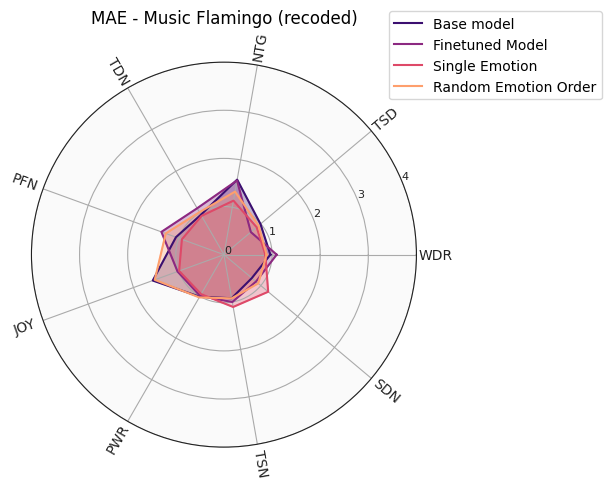

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'MAE - Music Flamingo (recoded)'}>)

In [743]:
mf_metrics = [mf_base_metrics[0]['mae'], mf_finetuned_metrics[0]['mae'], mf_single_emo_metrics[0]['mae'], mf_random_metrics[0]['mae']]
mf_legends = ['Base model', 'Finetuned Model', 'Single Emotion', 'Random Emotion Order']
emo_radar_charts(mf_metrics, mf_legends, title = 'MAE - Music Flamingo (recoded)', max_tick=4)

[0.064, 0.17, 0.059, 0.33, 0.268, 0.191, 0.292, 0.221, 0.205, 0.064]
[0, 0, 0, 0.011, 0.01, 0.178, 0.294, 0.167, 0, 0]
[0.139, 0.117, 0.1, 0.31, 0.352, 0.278, 0.241, 0.102, 0.101, 0.139]
[0.173, 0.119, 0.143, 0.214, 0.161, 0.182, 0.317, 0.242, 0.11, 0.173]


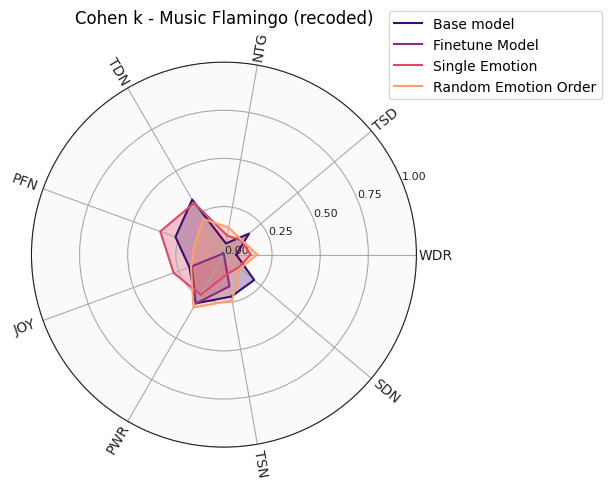

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Cohen k - Music Flamingo (recoded)'}>)

In [744]:
mf_metrics = [mf_base_metrics[0]['kappa'], mf_finetuned_metrics[0]['kappa'], mf_single_emo_metrics[0]['kappa'], mf_random_metrics[0]['kappa']]
mf_legends = ['Base model', 'Finetune Model', 'Single Emotion', 'Random Emotion Order']
emo_radar_charts(mf_metrics, mf_legends, title = 'Cohen k - Music Flamingo (recoded)', max_tick=1)

[48.881, 51.192, 30.611, 32.485, 26.989, 21.146, 26.911, 21.05, 18.206, 48.881]


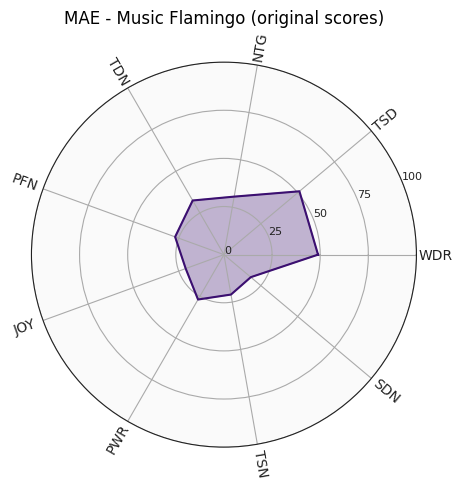

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'MAE - Music Flamingo (original scores)'}>)

In [745]:
emo_radar_charts([mf_og_metrics[0]['mae']], title = 'MAE - Music Flamingo (original scores)', max_tick=100)

[0.241, 0.248, 0.396, 0.239, 0.265, 0.393, 0.252, 0.23, 0.189, 0.241]
[0.489, 0.512, 0.306, 0.325, 0.27, 0.211, 0.269, 0.21, 0.182, 0.489]


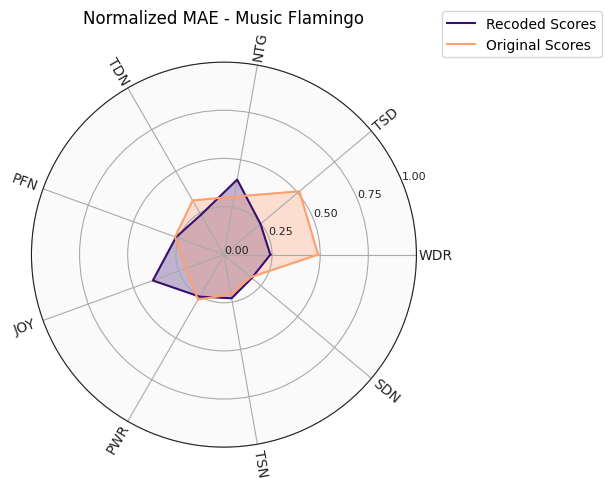

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Normalized MAE - Music Flamingo'}>)

In [746]:
mf_metrics = [mf_base_metrics[0]['nmae'], mf_og_metrics[0]['nmae']]
mf_legends = ['Recoded Scores', 'Original Scores']
emo_radar_charts(mf_metrics, mf_legends, title = 'Normalized MAE - Music Flamingo', max_tick=1)

### Voxtral Charts

[1.026, 0.922, 1.191, 1.139, 1.148, 2.165, 1.722, 1.062, 1.252, 1.026]
[1.035, 0.757, 0.991, 1.017, 0.878, 0.791, 1.0, 0.852, 0.652, 1.035]
[1.217, 1.504, 1.209, 1.661, 1.174, 1.287, 1.298, 1.8, 2.078, 1.217]
[0.868, 0.904, 1.33, 1.261, 1.391, 1.496, 1.212, 1.061, 1.096, 0.868]


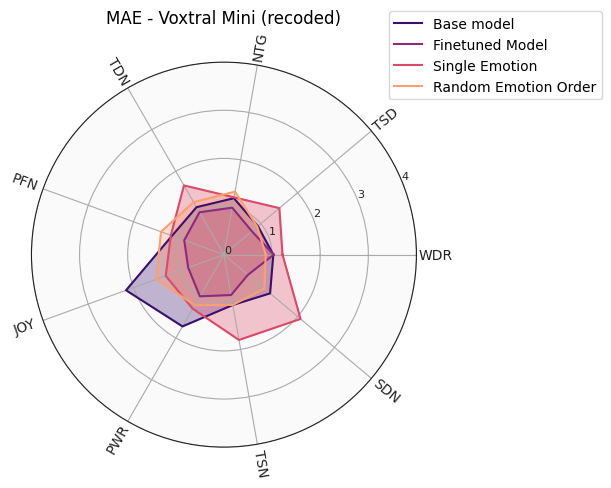

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'MAE - Voxtral Mini (recoded)'}>)

In [747]:
voxtral_metrics = [voxtral_base_metrics[0]['mae'], voxtral_finetuned_metrics[0]['mae'], voxtral_single_emo_metrics[0]['mae'], voxtral_random_metrics[0]['mae']]
voxtral_legends = ['Base model', 'Finetuned Model', 'Single Emotion', 'Random Emotion Order']
emo_radar_charts(voxtral_metrics, voxtral_legends, title = 'MAE - Voxtral Mini (recoded)', max_tick=4)

[0.085, 0.092, 0.081, 0.134, 0.254, 0.048, 0.094, 0.169, 0.158, 0.085]
[0.154, 0.201, 0.397, 0.435, 0.456, 0.469, 0.398, 0.38, 0.46, 0.154]
[0, 0.012, 0.012, 0.042, 0.145, 0, 0.022, 0.013, 0.011, 0]
[0.188, 0.16, 0.04, 0.061, 0.063, 0.097, 0.094, 0.093, 0.133, 0.188]


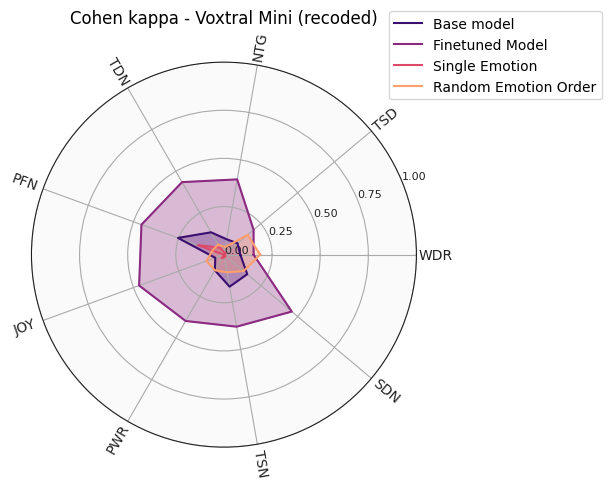

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Cohen kappa - Voxtral Mini (recoded)'}>)

In [748]:
voxtral_metrics = [voxtral_base_metrics[0]['kappa'], voxtral_finetuned_metrics[0]['kappa'], voxtral_single_emo_metrics[0]['kappa'], voxtral_random_metrics[0]['kappa']]
voxtral_legends = ['Base model', 'Finetuned Model', 'Single Emotion', 'Random Emotion Order']
emo_radar_charts(voxtral_metrics, voxtral_legends, title = 'Cohen kappa - Voxtral Mini (recoded)', max_tick=1)

[58.186, 49.087, 30.13, 32.375, 28.549, 15.451, 19.645, 18.59, 24.622, 58.186]


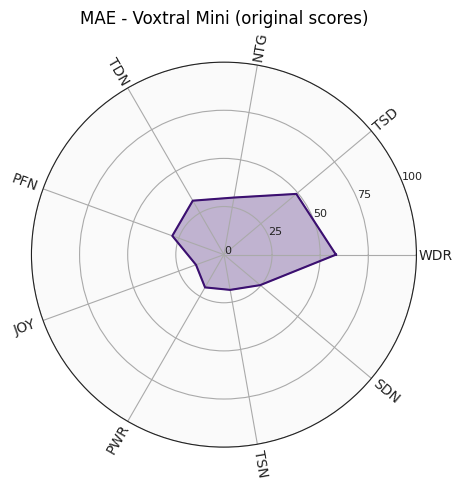

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'MAE - Voxtral Mini (original scores)'}>)

In [749]:
emo_radar_charts([voxtral_og_metrics[0]['mae']], title = 'MAE - Voxtral Mini (original scores)', max_tick=100)

[0.257, 0.23, 0.298, 0.285, 0.287, 0.541, 0.43, 0.265, 0.313, 0.257]
[0.582, 0.491, 0.301, 0.324, 0.285, 0.155, 0.196, 0.186, 0.246, 0.582]


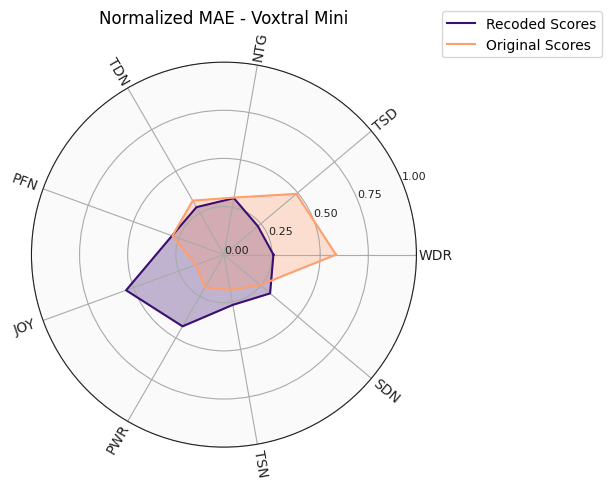

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Normalized MAE - Voxtral Mini'}>)

In [750]:
mf_metrics = [voxtral_base_metrics[0]['nmae'], voxtral_og_metrics[0]['nmae']]
mf_legends = ['Recoded Scores', 'Original Scores']
emo_radar_charts(mf_metrics, mf_legends, title = 'Normalized MAE - Voxtral Mini', max_tick=1)

### Music Flamingo v. Voxtral Charts

[0.965, 0.991, 1.583, 0.957, 1.061, 1.574, 1.009, 0.92, 0.757, 0.965]
[1.096, 0.73, 1.565, 1.113, 1.383, 1.026, 0.991, 1.0, 0.87, 1.096]
[1.026, 0.922, 1.191, 1.139, 1.148, 2.165, 1.722, 1.062, 1.252, 1.026]
[1.035, 0.757, 0.991, 1.017, 0.878, 0.791, 1.0, 0.852, 0.652, 1.035]


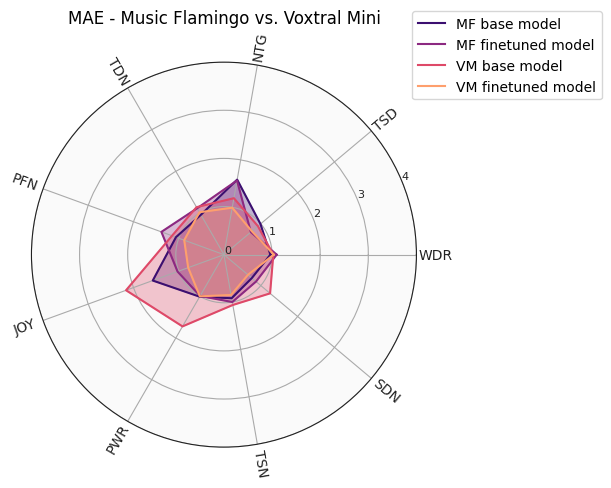

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'MAE - Music Flamingo vs. Voxtral Mini'}>)

In [751]:
metrics = [mf_base_metrics[0]['mae'],  mf_finetuned_metrics[0]['mae'], voxtral_base_metrics[0]['mae'],voxtral_finetuned_metrics[0]['mae']]
legends = ['MF base model', 'MF finetuned model','VM base model',  'VM finetuned model']
emo_radar_charts(metrics, legends, title='MAE - Music Flamingo vs. Voxtral Mini')

[0.064, 0.17, 0.059, 0.33, 0.268, 0.191, 0.292, 0.221, 0.205, 0.064]
[0, 0, 0, 0.011, 0.01, 0.178, 0.294, 0.167, 0, 0]
[0.085, 0.092, 0.081, 0.134, 0.254, 0.048, 0.094, 0.169, 0.158, 0.085]
[0.154, 0.201, 0.397, 0.435, 0.456, 0.469, 0.398, 0.38, 0.46, 0.154]


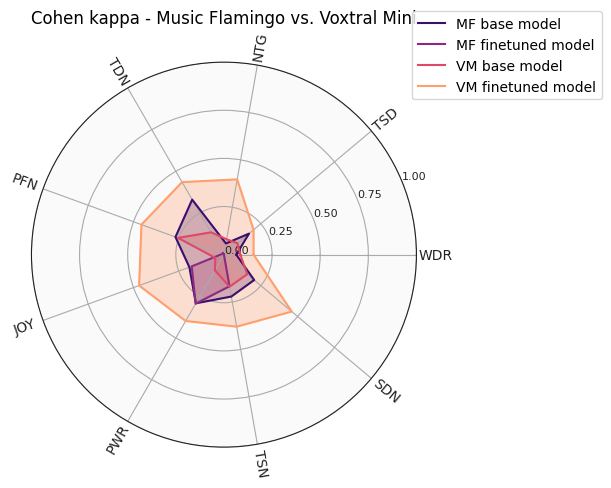

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Cohen kappa - Music Flamingo vs. Voxtral Mini'}>)

In [752]:
metrics = [mf_base_metrics[0]['kappa'],  mf_finetuned_metrics[0]['kappa'], voxtral_base_metrics[0]['kappa'],voxtral_finetuned_metrics[0]['kappa']]
legends = ['MF base model', 'MF finetuned model','VM base model',  'VM finetuned model']
emo_radar_charts(metrics, legends, title='Cohen kappa - Music Flamingo vs. Voxtral Mini', max_tick=1)

[0.241, 0.248, 0.396, 0.239, 0.265, 0.393, 0.252, 0.23, 0.189, 0.241]
[0.274, 0.183, 0.391, 0.278, 0.346, 0.257, 0.248, 0.25, 0.217, 0.274]
[0.489, 0.512, 0.306, 0.325, 0.27, 0.211, 0.269, 0.21, 0.182, 0.489]
[0.257, 0.23, 0.298, 0.285, 0.287, 0.541, 0.43, 0.265, 0.313, 0.257]
[0.259, 0.189, 0.248, 0.254, 0.22, 0.198, 0.25, 0.213, 0.163, 0.259]
[0.582, 0.491, 0.301, 0.324, 0.285, 0.155, 0.196, 0.186, 0.246, 0.582]


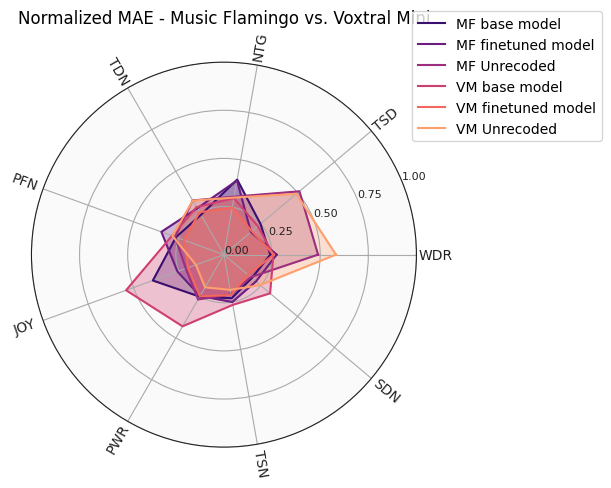

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Normalized MAE - Music Flamingo vs. Voxtral Mini'}>)

In [753]:
metrics = [mf_base_metrics[0]['nmae'],  mf_finetuned_metrics[0]['nmae'], mf_og_metrics[0]['nmae'],voxtral_base_metrics[0]['nmae'],voxtral_finetuned_metrics[0]['nmae'], voxtral_og_metrics[0]['nmae']]
legends = ['MF base model', 'MF finetuned model', 'MF Unrecoded','VM base model', 'VM finetuned model', 'VM Unrecoded']
emo_radar_charts(metrics, legends, title='Normalized MAE - Music Flamingo vs. Voxtral Mini', max_tick=1)

### Global scores Charts

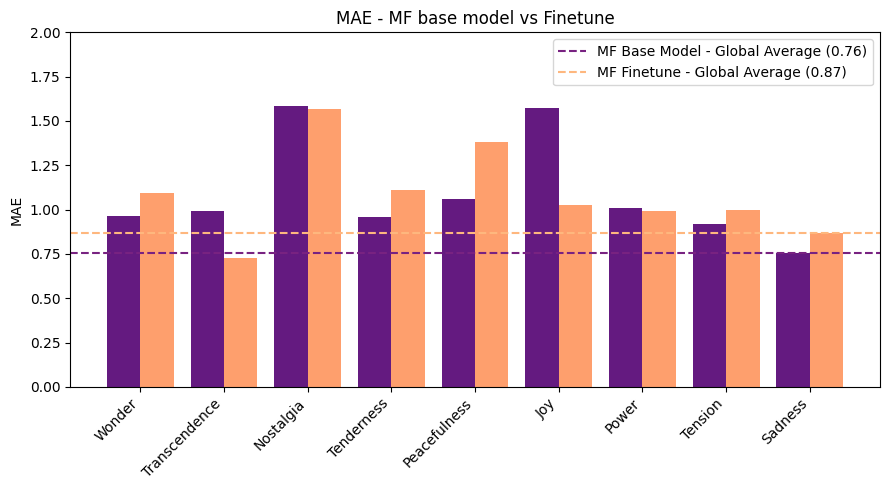

In [837]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(emotions_col))
width = .4

ax.bar(x - width/2,
       mf_base_metrics[0]['mae'],
       width=width,
       color=plt.cm.magma(0.3))
ax.bar(x + width/2,
       mf_finetuned_metrics[0]['mae'],
       width=width,
       color=plt.cm.magma(0.8))

ax.axhline(y=mf_base_metrics[1]['mae'],
           color=plt.cm.magma(0.35),
           linewidth=1.5,
           linestyle='--',
           label=f"MF Base Model - Global Average ({mf_base_metrics[1]['mae']:.2})")
ax.axhline(y=mf_finetuned_metrics[1]['mae'],
           color=plt.cm.magma(0.85),
           linewidth=1.5,
           linestyle='--',
           label=f"MF Finetune - Global Average ({mf_finetuned_metrics[1]['mae']:.2})")

ax.set_ylabel('MAE')
ax.set_title('MAE - MF base model vs Finetune')

plt.xticks(ticks=x, labels=emotions_col, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 2)

plt.tight_layout()
plt.show()

### Loss chart

In [757]:
mf_train_loss = [0.2926,0.0412,0.0404,0.0397,0.0391,0.0385,0.0375]
mf_val_loss = [0.0422,0.0404,0.0401,0.0396,0.0401,0.0401,0.0406]
vm_train_loss = [0.2002, 0.1767, 0.1654, 0.1571, 0.1474, 0.1365, 0.1243]
vm_val_loss = [0.1865 ,0.1718 ,0.1778 ,0.1701 ,0.1789 ,0.1885 ,0.1868]

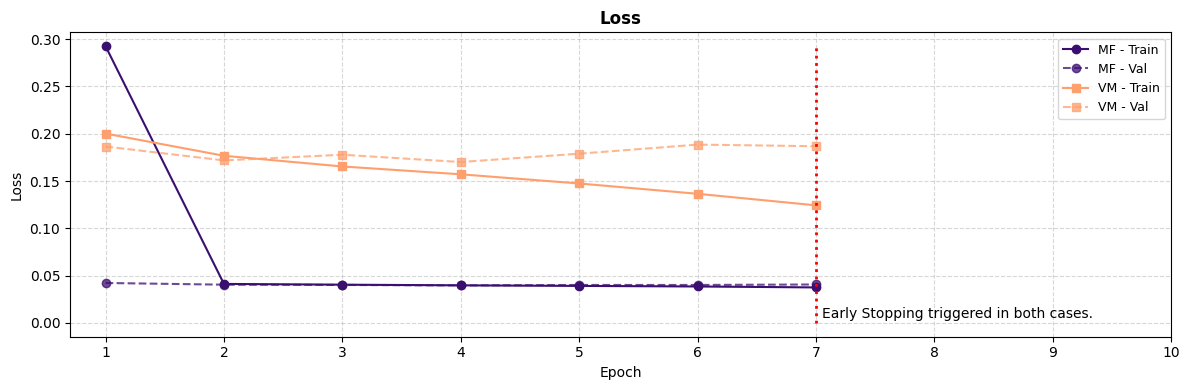

In [789]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(range(1,len(mf_train_loss)+1),  mf_train_loss,  marker="o", lw=1.5, label="MF - Train",  color=plt.cm.magma(.2))
ax.plot(range(1,len(mf_val_loss)+1),  mf_val_loss, marker="o", lw=1.5, ls="--", label="MF - Val", color=plt.cm.magma(.2), alpha=0.75)
ax.plot(range(1,len(vm_train_loss)+1), vm_train_loss, marker="s", lw=1.5, label="VM - Train", color=plt.cm.magma(.8))
ax.plot(range(1,len(vm_val_loss)+1), vm_val_loss,marker="s", lw=1.5, ls="--", label="VM - Val", color=plt.cm.magma(.8), alpha=0.75)
plt.vlines(x=7, ymin=0, ymax=max(mf_train_loss), colors='red', ls=':', lw=2)

ax.annotate('Early Stopping triggered in both cases.', xy=(7, 0.05), xytext=(7.05, 0.005))

ax.set_title("Loss", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_xticks(np.linspace(1,10,10))
ax.legend(fontsize=9); ax.grid(True, ls="--", alpha=0.5)

fig.tight_layout()
plt.show()